# Analyses

This notebook contains the business questions and statistical analyses.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind, f_oneway, mannwhitneyu
from sqlalchemy import create_engine

## Loading the dataset

In [ ]:
server = r'LAPTOP-OCKRNGU5\SQLEXPRESS'
database = 'SupplyChainDB'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)

query = """
SELECT
  order_id,
  order_customer_id AS customer_id,
  order_date_dateorders AS order_datetime,
  shipping_date_dateorders AS shipping_datetime,
  days_for_shipment_scheduled AS scheduled_ship_days,
  days_for_shipping_real AS actual_ship_days,
  (days_for_shipping_real - days_for_shipment_scheduled) AS shipping_delay_days,
  CASE
    WHEN late_delivery_risk IS NOT NULL THEN late_delivery_risk
    WHEN (days_for_shipping_real - days_for_shipment_scheduled) > 0 THEN 1
    ELSE 0
  END AS is_late_flag,
  delivery_status,
  shipping_mode,
  order_status,
  order_region,
  order_state,
  market,
  order_country,
  order_city,
  product_category_id,
  category_name,
  order_item_product_price,
  order_item_quantity,
  order_item_discount,
  order_item_discount_rate,
  order_item_total,
  sales,
  benefit_per_order,
  order_profit_per_order,
  order_item_profit_ratio,
  CASE
    WHEN sales = 0 OR sales IS NULL THEN NULL
    ELSE ROUND(order_profit_per_order / NULLIF(sales, 0), 6)
  END AS profit_margin,
  DATEPART(year, order_date_dateorders) AS order_year,
  DATEPART(month, order_date_dateorders) AS order_month,
  DATEPART(weekday, order_date_dateorders) AS order_weekday
FROM dbo.supply_chain_data
WHERE
  days_for_shipping_real IS NOT NULL
  AND days_for_shipment_scheduled IS NOT NULL
  AND (order_profit_per_order IS NOT NULL OR sales IS NOT NULL);
"""

supply_chain = pd.read_sql(query, engine)
supply_chain.style

## 1. Does shipping mode significantly affect delivery performance?

A question would rise if the different late delivery rates between shipping modes significantly different. We'll use chi-squared test of independence.

Initial Hypothesis:

H₀: Shipping mode and late delivery are independent.

H₁: Shipping mode and late delivery are associated.

In [3]:
table = pd.crosstab(
    supply_chain['shipping_mode'],
    supply_chain['is_late_flag']
)

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.4g}")

Chi-square: 37716.04
p-value: 0


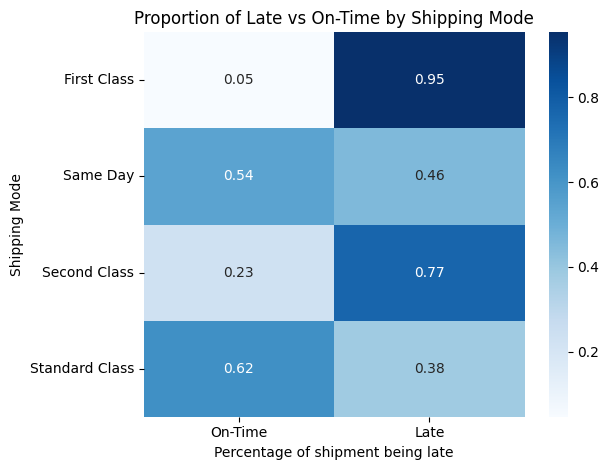

In [10]:
table_pct = table.div(table.sum(axis=1), axis=0)

sns.heatmap(table_pct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Proportion of Late vs On-Time by Shipping Mode")
plt.ylabel("Shipping Mode")
plt.xlabel("Percentage of shipment being late")
plt.xticks(ticks=[0.5, 1.5], labels=["On-Time", "Late"], rotation=0)
plt.tight_layout()
plt.show()


### With the p-value being 0 and p < 0.05, then we have evidence that shipping mode and late delivery are associated. In other words, for example, your shipment is prone to being late by choosing first class or it is prone to be on-time with Standard Class.

## 2. Does shipping delay affect profitability?

One of the core questions of the project. We'll first use independent t-test and consider using Mann-Whitney U test due to the skewness of the distribution.

Initial Hypothesis:

H₀: The mean profit for late orders equals the mean profit for on‑time orders.

H₁: The mean profit for late orders is different from the mean profit for on‑time orders.

In [4]:
supply_chain.groupby('is_late_flag')['benefit_per_order'].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
is_late_flag,,,,
0,81542,22.403808,31.68,103.163253
1,98977,21.621707,31.43,105.467754


In [ ]:
Q1 = supply_chain['benefit_per_order'].quantile(0.25)
Q3 = supply_chain['benefit_per_order'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered = supply_chain[
    (supply_chain['benefit_per_order'] >= lower_bound) &
    (supply_chain['benefit_per_order'] <= upper_bound)
]

late = filtered.loc[filtered['is_late_flag'] == 1, 'benefit_per_order']
on_time = filtered.loc[filtered['is_late_flag'] == 0, 'benefit_per_order']

t_stat, p_value = ttest_ind(late, on_time, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -1.573466431717265
p-value: 0.11561288626748353


In [ ]:
late = supply_chain.loc[supply_chain['is_late_flag'] == 1, 'benefit_per_order']
on_time = supply_chain.loc[supply_chain['is_late_flag'] == 0, 'benefit_per_order']

stat, p = mannwhitneyu(
    late,       
    on_time,
    alternative='two-sided'
)

print('t_statistic:', stat)
print('p_value:', p)

t_statistic: 4021595981.5
p_value: 0.21057347628995415


### With significance value of 0.05, both test failed to reject the null hypothesis. We have insufficient evidence to say that the mean profit for on-time and late shipments are different.

## 3. Is profitability different across shipping modes?

Comparing the mean profits of shipping modes from one another. With this,  we're going to use one-way ANOVA.

Initial Hypothesis:

H₀: All shipping modes have the same mean benefit per order.

H₁: At least one shipping mode has a different mean benefit per order.

In [18]:
groups = [
    group['benefit_per_order'].dropna()
    for _, group in supply_chain.groupby('shipping_mode')
]

f_stat, p = f_oneway(*groups)

print('f_statistic:', f_stat)
print('p_value:', p)

f_statistic: 1.9791817108864236
p_value: 0.1146926980244713


### With a significance level of 0.05, we fail to reject the null hypothesis. There is insufficient evidence to conclude that mean profit differs across shipping modes. Observed differences are likely due to sampling variability.

## 4. Does profitability vary by month?

One observation during EDA is that October has the highest average profit per order by month. So, we're going to perform a one-way ANOVA to determine if there is sufficient evidence to support this.

Inititial Hypothesis:

H₀: The mean profit is the same for every order month.

H₁: At least one order month has a different mean profit.

In [20]:
groups = [
    group['benefit_per_order'].dropna()
    for _, group in supply_chain.groupby('order_month')
]

f_stat, p = f_oneway(*groups)

print('f_statistic:', f_stat)
print('p_value:', p)

f_statistic: 2.539943799008764
p_value: 0.0033089792665012357


### With a significance value of 0.05 and a p-value lower than that, we have significant evidence that there is at least one month that is significantly different than the other in terms of mean profits.